In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
bmw = pd.read_csv('E:\TRIPLETEN\kaggle df\BMW sales data (2010-2024).csv')
bmw.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low


In [3]:
bmw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  object 
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  object 
 3   Color                 50000 non-null  object 
 4   Fuel_Type             50000 non-null  object 
 5   Transmission          50000 non-null  object 
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 4.2+ MB


In [4]:
bmw.columns

Index(['Model', 'Year', 'Region', 'Color', 'Fuel_Type', 'Transmission',
       'Engine_Size_L', 'Mileage_KM', 'Price_USD', 'Sales_Volume',
       'Sales_Classification'],
      dtype='object')

In [5]:
bmw.describe()

,Year,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2017.015700,3.247180,100307.203140,75034.600900,5067.514680
std,4.324459,1.009078,57941.509344,25998.248882,2856.767125
min,2010.000000,1.500000,3.000000,30000.000000,100.000000
25%,2013.000000,2.400000,50178.000000,52434.750000,2588.000000
50%,2017.000000,3.200000,100388.500000,75011.500000,5087.000000
75%,2021.000000,4.100000,150630.250000,97628.250000,7537.250000
max,2024.000000,5.000000,199996.000000,119998.000000,9999.000000


In [6]:
bmw.shape

(50000, 11)

In [7]:
bmw.isna().sum()

Model                   0
Year                    0
Region                  0
Color                   0
Fuel_Type               0
Transmission            0
Engine_Size_L           0
Mileage_KM              0
Price_USD               0
Sales_Volume            0
Sales_Classification    0
dtype: int64

In [8]:
bmw.nunique()

Model                      11
Year                       15
Region                      6
Color                       6
Fuel_Type                   4
Transmission                2
Engine_Size_L              36
Mileage_KM              44347
Price_USD               38246
Sales_Volume             9845
Sales_Classification        2
dtype: int64

In [9]:
bmw['Model'].value_counts()

Model
7 Series    4666
i3          4618
i8          4606
3 Series    4595
5 Series    4592
X1          4570
X3          4497
X5          4487
M5          4478
X6          4478
M3          4413
Name: count, dtype: int64

In [10]:
bmw['Region'].value_counts()

Region
Asia             8454
Middle East      8373
North America    8335
Europe           8334
Africa           8253
South America    8251
Name: count, dtype: int64

#### Tabla comparativa del conteo general sobre los modelos por region por año

In [11]:
cantidad_x_año = pd.pivot_table(bmw,
              index=['Model', 'Region'],
              columns='Year',
              aggfunc='size',
              fill_value=0)
cantidad_x_año.head(20)

Year                    2010  2011  2012  2013  2014  2015  2016  2017  2018  \
Model    Region                                                                
3 Series Africa           60    46    44    55    47    47    43    57    51   
         Asia             42    54    45    52    62    55    54    58    58   
         Europe           56    47    53    55    45    46    51    45    53   
         Middle East      47    54    44    49    57    60    48    45    55   
         North America    58    46    46    36    53    56    68    44    52   
         South America    54    46    47    52    58    51    63    58    47   
5 Series Africa           55    45    51    59    47    59    55    53    50   
         Asia             49    48    55    52    55    60    57    44    53   
         Europe           43    48    54    41    49    63    49    56    50   
         Middle East      59    57    46    37    40    53    57    40    48   
         North America    45    55    42    48    57    54    60    59    35   
         South America    48    52    51    59    48    39    65    54    44   
7 Series Africa           53    39    48    46    58    54    35    52    51   
         Asia             45    57    52    54    55    52    55    59    44   
         Europe           42    53    44    55    49    52    46    58    45   
         Middle East      45    51    49    50    69    55    55    65    50   
         North America    43    61    48    55    46    62    60    58    45   
         South America    51    58    54    49    43    51    48    51    58   
M3       Africa           43    47    59    43    48    48    46    42    55   
         Asia             59    45    47    49    63    52    55    55    53   

Year                    2019  2020  2021  2022  2023  2024  
Model    Region                                             
3 Series Africa           55    52    58    51    45    46  
         Asia             40    35    49    62    47    54  
         Europe           47    60    51    52    51    52  
         Middle East      42    65    63    46    48    49  
         North America    44    42    53    57    57    48  
         South America    63    41    49    46    51    49  
5 Series Africa           57    62    42    56    46    52  
         Asia             53    56    54    47    43    61  
         Europe           53    40    52    54    46    56  
         Middle East      43    46    54    50    58    55  
         North America    64    49    45    38    49    41  
         South America    45    54    48    58    50    63  
7 Series Africa           46    52    58    55    41    50  
         Asia             43    37    60    48    47    76  
         Europe           40    54    60    49    55    61  
         Middle East      55    59    49    57    57    44  
         North America    57    52    46    53    52    53  
         South America    46    51    51    68    57    44  
M3       Africa           50    45    42    45    40    41  
         Asia             36    49    55    43    64    54

In [12]:
#Resetear indice para convertir model y Region en columnas
bmw_plot = cantidad_x_año.reset_index().melt(id_vars=['Model','Region'],
                                             var_name='Year',
                                             value_name='Count')
cant_vehiculos = bmw_plot.sort_values(by='Count', ascending=False)
cant_vehiculos.head(20)

,Model,Region,Year,Count
962,X3,Europe,2024,76
937,7 Series,Asia,2024,76
975,X6,Middle East,2024,72
177,X5,Middle East,2012,72
812,M3,Europe,2022,71
554,M5,Europe,2018,69
279,7 Series,Middle East,2014,69
62,i8,Europe,2010,69
226,M5,North America,2013,69
988,i8,North America,2024,68


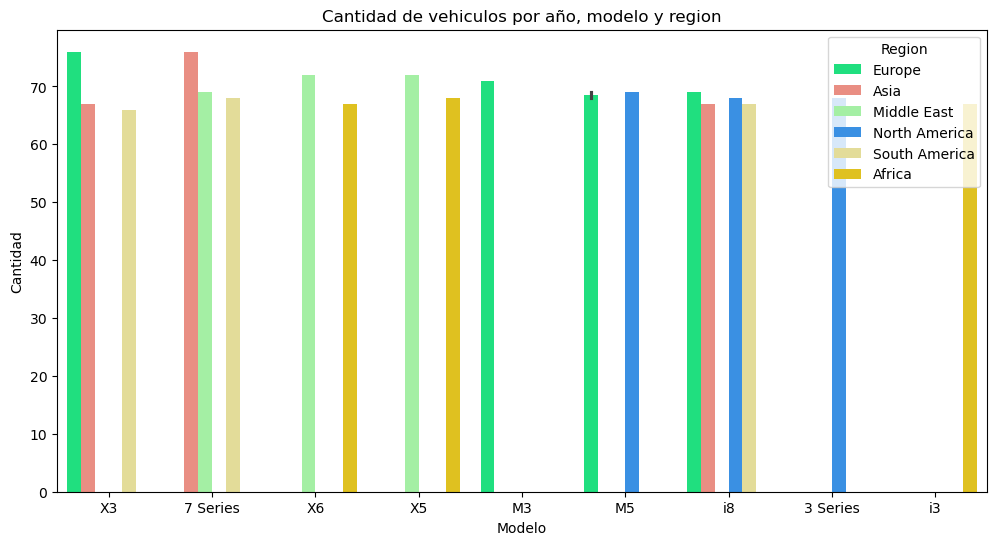

In [13]:
plt.figure(figsize=(12,6))
palette = {'Africa':'gold','Europe':'springgreen', 'Asia': 'salmon', 'South America': 'khaki', 'North America': 'dodgerblue','Middle East': 'palegreen'}
sns.barplot(data=cant_vehiculos.head(20), x='Model', y='Count', hue='Region', palette=palette)
plt.title('Cantidad de vehiculos por año, modelo y region')
plt.xlabel('Modelo')
plt.ylabel('Cantidad')
plt.show()

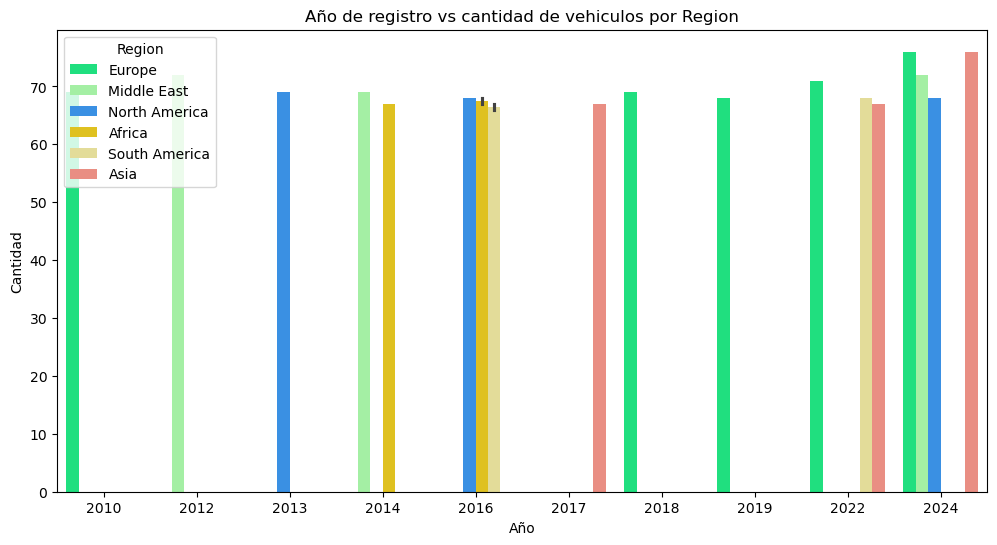

In [14]:
#Graficamos cantidad de vehiculos segun el año de registro por cada region , para conocer en que region y año se vendieron mas y menos
plt.figure(figsize=(12,6))
palette = {'Africa':'gold','Europe':'springgreen', 'Asia': 'salmon', 'South America': 'khaki', 'North America': 'dodgerblue','Middle East': 'palegreen'}
sns.barplot(data=cant_vehiculos.head(20), x='Year', y='Count', hue='Region', palette=palette)
plt.title('Año de registro vs cantidad de vehiculos por Region')
plt.xlabel('Año')
plt.ylabel('Cantidad')
plt.show()

In [15]:
regiones = cantidad_x_año.loc[['X3','7 Series']]
regiones.sort_values(by=2024, ascending=False)

Year                    2010  2011  2012  2013  2014  2015  2016  2017  2018  \
Model    Region                                                                
X3       Europe           48    47    54    46    49    37    45    57    42   
7 Series Asia             45    57    52    54    55    52    55    59    44   
         Europe           42    53    44    55    49    52    46    58    45   
X3       Africa           53    51    49    62    46    52    54    47    40   
         North America    62    61    35    52    43    55    57    55    57   
7 Series North America    43    61    48    55    46    62    60    58    45   
X3       South America    42    43    65    44    44    56    66    44    34   
7 Series Africa           53    39    48    46    58    54    35    52    51   
X3       Asia             51    35    55    43    49    45    56    39    57   
7 Series Middle East      45    51    49    50    69    55    55    65    50   
         South America    51    58    54    49    43    51    48    51    58   
X3       Middle East      54    42    61    53    53    42    54    47    56   

Year                    2019  2020  2021  2022  2023  2024  
Model    Region                                             
X3       Europe           46    44    47    62    42    76  
7 Series Asia             43    37    60    48    47    76  
         Europe           40    54    60    49    55    61  
X3       Africa           45    37    60    34    47    54  
         North America    63    46    40    56    55    53  
7 Series North America    57    52    46    53    52    53  
X3       South America    56    52    46    44    48    50  
7 Series Africa           46    52    58    55    41    50  
X3       Asia             52    46    49    67    48    49  
7 Series Middle East      55    59    49    57    57    44  
         South America    46    51    51    68    57    44  
X3       Middle East      42    47    56    62    49    41

In [16]:
volumen_vtas = bmw[['Model','Year','Region','Price_USD','Sales_Volume','Sales_Classification']]
volumen_vtas.sort_values(by='Sales_Volume', ascending=False).head()

,Model,Year,Region,Price_USD,Sales_Volume,Sales_Classification
47953,5 Series,2024,South America,88572,9999,High
27113,X3,2011,Africa,79124,9999,High
38529,M3,2022,Europe,38126,9999,High
39518,3 Series,2017,North America,64641,9999,High
13521,7 Series,2024,Europe,71167,9999,High


In [17]:
#Conteo por clasificacion de ventas segun df, bajas y altas
volumen_vtas['Sales_Classification'].value_counts()

Sales_Classification
Low     34754
High    15246
Name: count, dtype: int64

In [18]:
#Segmentacion del volumen de ventas por clasificacion segun el df, para conocer los valores a partir de cuanto se considera que volumen
volumen_vtas.groupby('Sales_Classification')['Sales_Volume'].agg(['min','max'])

,min,max
Sales_Classification,,
High,7000,9999
Low,100,6999


In [19]:
#Agregamos nueva columna, donde dividimos y clasificamos segun el precio de venta, con base en cuartiles
volumen_vtas['Segmento_precio_venta'] = pd.qcut(volumen_vtas['Price_USD'],q=4,labels=['Muy bajo', 'Bajo', 'Medio', 'Alto'])
conteo_segmentos = volumen_vtas['Segmento_precio_venta'].value_counts()
volumen_vtas

C:\Users\dell\AppData\Local\Temp\ipykernel_15576\3094305156.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  volumen_vtas['Segmento_precio_venta'] = pd.qcut(volumen_vtas['Price_USD'],q=4,labels=['Muy bajo', 'Bajo', 'Medio', 'Alto'])


,Model,Year,Region,Price_USD,Sales_Volume,Sales_Classification,Segmento_precio_venta
0,5 Series,2016,Asia,98740,8300,High,Alto
1,i8,2013,North America,79219,3428,Low,Medio
2,5 Series,2022,North America,113265,6994,Low,Alto
3,X3,2024,Middle East,60971,4047,Low,Bajo
4,7 Series,2020,South America,49898,3080,Low,Muy bajo
...,...,...,...,...,...,...,...
49995,i3,2014,Asia,42932,8182,High,Muy bajo
49996,i3,2023,Middle East,48714,9816,High,Muy bajo
49997,5 Series,2010,Middle East,46126,8280,High,Muy bajo
49998,i3,2020,Asia,58566,9486,High,Bajo


Clasificar el volumen de ventas, segmentar por volumen de ventas <br>
Identificar a partir de cuanto se considera High y Low <br>
agregar el año a la tabla y la region <br>
una vez conocidos y separados esos valores aplicamos analisis estadistico y modelos predictivos para predecir ventas <br>

In [20]:
#Separamos y clasificamos con base en los precios de venta desde muy bajo hasta alto, con base en division por cuartiles
volumen_vtas.groupby('Segmento_precio_venta')['Price_USD'].agg(['min','max'])

C:\Users\dell\AppData\Local\Temp\ipykernel_15576\3854956902.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  volumen_vtas.groupby('Segmento_precio_venta')['Price_USD'].agg(['min','max'])


,min,max
Segmento_precio_venta,,
Muy bajo,30000,52434
Bajo,52435,75010
Medio,75013,97628
Alto,97629,119998


Grafica boxplots para conocer la distribucion <br>
Aplicamos de forma manual el calculo para conocer los indices intercuartilicos<br>

In [21]:
volumen_vtas['Ventas_totales_USD'] = volumen_vtas['Price_USD'] * volumen_vtas['Sales_Volume']
volumen_vtas.head()

C:\Users\dell\AppData\Local\Temp\ipykernel_15576\118433961.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  volumen_vtas['Ventas_totales_USD'] = volumen_vtas['Price_USD'] * volumen_vtas['Sales_Volume']


,Model,Year,Region,Price_USD,Sales_Volume,Sales_Classification,Segmento_precio_venta,Ventas_totales_USD
0,5 Series,2016,Asia,98740,8300,High,Alto,819542000
1,i8,2013,North America,79219,3428,Low,Medio,271562732
2,5 Series,2022,North America,113265,6994,Low,Alto,792175410
3,X3,2024,Middle East,60971,4047,Low,Bajo,246749637
4,7 Series,2020,South America,49898,3080,Low,Muy bajo,153685840


In [22]:
vtas_modelo_region = volumen_vtas.groupby(['Region','Year','Model'])['Ventas_totales_USD'].sum().reset_index().sort_values(by='Ventas_totales_USD', 
                                                                                                                           ascending=False)
vtas_modelo_region.head()

,Region,Year,Model,Ventas_totales_USD
321,Asia,2024,7 Series,32075092303
657,Middle East,2024,X6,29309875495
906,South America,2017,M5,28502301874
824,North America,2024,i8,28429954799
465,Europe,2022,M3,28363675413


In [23]:
vtas_modelo_region['Ventas_Billones_USD'] = vtas_modelo_region['Ventas_totales_USD'].apply(lambda x:round(x/1e9,2))
vtas_modelo_region

,Region,Year,Model,Ventas_totales_USD,Ventas_Billones_USD
321,Asia,2024,7 Series,32075092303,32.08
657,Middle East,2024,X6,29309875495,29.31
906,South America,2017,M5,28502301874,28.50
824,North America,2024,i8,28429954799,28.43
465,Europe,2022,M3,28363675413,28.36
...,...,...,...,...,...
421,Europe,2018,M3,11033659889,11.03
975,South America,2023,X5,10875483703,10.88
194,Asia,2012,X5,10849523636,10.85
734,North America,2016,X6,10677792718,10.68


In [24]:
vtas_modelo_region.isna().sum()

Region                 0
Year                   0
Model                  0
Ventas_totales_USD     0
Ventas_Billones_USD    0
dtype: int64

#### Agregamos una tabla dinamica si es que se quiere localizar algun valor en especifico, el comparativo de ventas por modelo, region y año

In [25]:
pivot_modelo = pd.pivot_table(vtas_modelo_region,
                              index=['Model','Region'],
                              columns='Year',
                              values='Ventas_Billones_USD',
                              aggfunc='sum',
                              fill_value=0)
pivot_modelo.head()

Year                     2010   2011   2012   2013   2014   2015   2016  \
Model    Region                                                           
3 Series Africa         24.14  19.91  18.60  22.27  17.69  19.75  19.25   
         Asia           16.00  20.48  18.33  19.51  25.76  23.89  21.12   
         Europe         25.73  17.12  17.85  18.51  18.64  17.47  20.37   
         Middle East    15.83  21.25  17.03  17.26  22.69  21.80  19.14   
         North America  21.68  18.30  16.64  13.39  22.33  22.77  26.48   

Year                     2017   2018   2019   2020   2021   2022   2023   2024  
Model    Region                                                                 
3 Series Africa         20.06  20.23  22.86  21.13  18.82  18.43  18.45  18.53  
         Asia           18.55  23.64  15.18  14.43  18.73  24.94  19.88  22.26  
         Europe         18.88  20.96  19.75  26.52  21.78  18.34  21.12  21.15  
         Middle East    14.62  21.79  16.02  23.32  26.78  17.67  15.06  20.64  
         North America  14.92  17.64  15.93  20.27  20.09  23.18  23.92  15.86

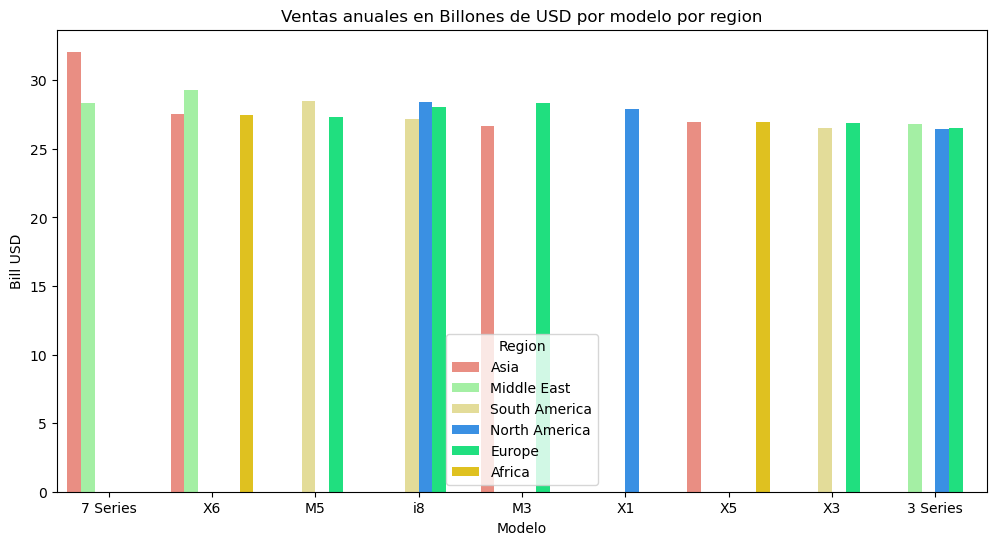

In [26]:
plt.figure(figsize=(12,6))
palette = {'Africa':'gold','Europe':'springgreen', 'Asia': 'salmon', 'South America': 'khaki', 'North America': 'dodgerblue','Middle East': 'palegreen'}
sns.barplot(data=vtas_modelo_region.head(20), x='Model', y='Ventas_Billones_USD', hue='Region', palette=palette)
plt.title('Ventas anuales en Billones de USD por modelo por region')
plt.xlabel('Modelo')
plt.ylabel('Bill USD')
plt.show()

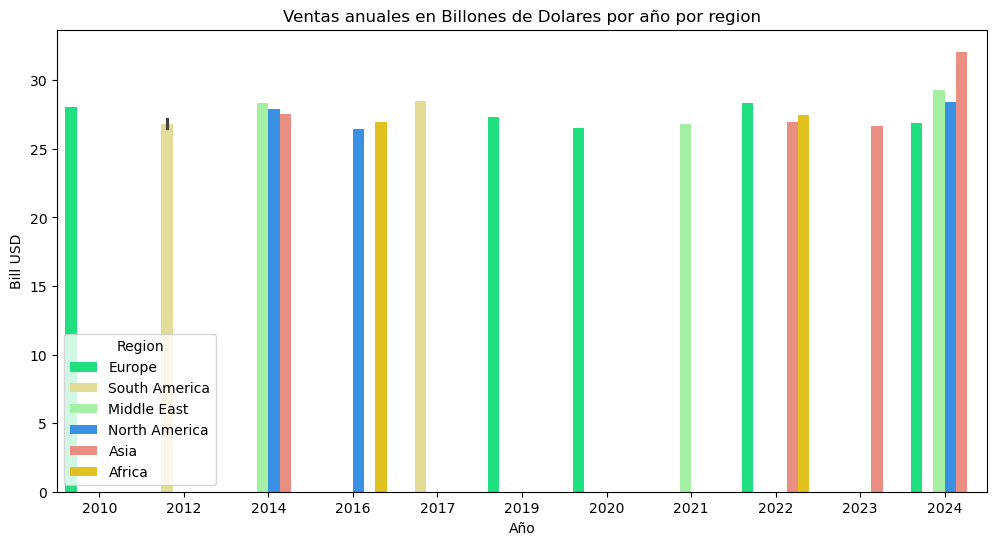

In [27]:
plt.figure(figsize=(12,6))
palette = {'Africa':'gold','Europe':'springgreen', 'Asia': 'salmon', 'South America': 'khaki', 'North America': 'dodgerblue','Middle East': 'palegreen'}
sns.barplot(data=vtas_modelo_region.head(20), x='Year', y='Ventas_Billones_USD', hue='Region', palette=palette)
plt.title('Ventas anuales en Billones de Dolares por año por region')
plt.xlabel('Año')
plt.ylabel('Bill USD')
plt.show()

Agregamos un grafico con la distribucion por cuartiles

In [28]:
Q1 = volumen_vtas['Sales_Volume'].quantile(0.25)
Q2 = volumen_vtas['Sales_Volume'].quantile(0.50)  # Mediana
Q3 = volumen_vtas['Sales_Volume'].quantile(0.75)
IQR = Q3 - Q1

print("Q1:", Q1)
print("Mediana (Q2):", Q2)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 2588.0
Mediana (Q2): 5087.0
Q3: 7537.25
IQR: 4949.25


Graficamos

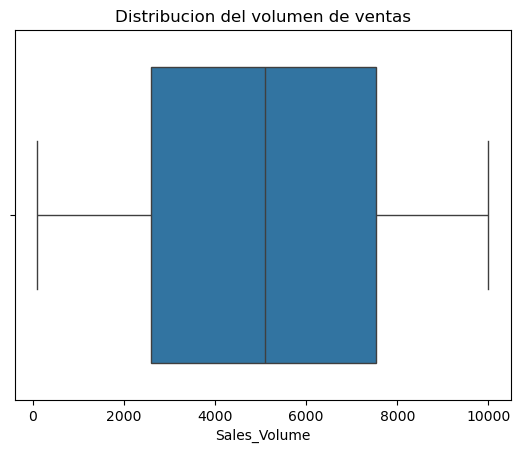

In [29]:
sns.boxplot(x=volumen_vtas['Sales_Volume'])
plt.title('Distribucion del volumen de ventas')
plt.show()

In [30]:
bmw

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low
...,...,...,...,...,...,...,...,...,...,...,...
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High
49996,i3,2023,Middle East,Silver,Electric,Manual,4.2,147396,48714,9816,High
49997,5 Series,2010,Middle East,Red,Petrol,Automatic,4.5,174939,46126,8280,High
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High


In [31]:
bmw['Total_Sales_USD'] = bmw['Price_USD'] * bmw['Sales_Volume']
bmw.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,Total_Sales_USD
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High,819542000
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low,271562732
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low,792175410
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low,246749637
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low,153685840


In [32]:
bmw['Sales_Millions_USD'] = bmw['Total_Sales_USD'].apply(lambda x:round(x/1e6,2))
bmw

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,Total_Sales_USD,Sales_Millions_USD
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High,819542000,819.54
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low,271562732,271.56
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low,792175410,792.18
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low,246749637,246.75
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low,153685840,153.69
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High,351269624,351.27
49996,i3,2023,Middle East,Silver,Electric,Manual,4.2,147396,48714,9816,High,478176624,478.18
49997,5 Series,2010,Middle East,Red,Petrol,Automatic,4.5,174939,46126,8280,High,381923280,381.92
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High,555557076,555.56


In [33]:
bmw.columns

Index(['Model', 'Year', 'Region', 'Color', 'Fuel_Type', 'Transmission',
       'Engine_Size_L', 'Mileage_KM', 'Price_USD', 'Sales_Volume',
       'Sales_Classification', 'Total_Sales_USD', 'Sales_Millions_USD'],
      dtype='object')

In [34]:
bmw.isna().sum()

Model                   0
Year                    0
Region                  0
Color                   0
Fuel_Type               0
Transmission            0
Engine_Size_L           0
Mileage_KM              0
Price_USD               0
Sales_Volume            0
Sales_Classification    0
Total_Sales_USD         0
Sales_Millions_USD      0
dtype: int64

Antes de transformar los valores con OHE, los pasamos a categoricos

In [35]:
bmw[['Model', 
     'Year', 
     'Region', 
     'Color', 
     'Fuel_Type', 
     'Transmission',
     'Sales_Classification']] = bmw[['Model', 
                                      'Year',
                                      'Region', 
                                      'Color',
                                      'Fuel_Type',
                                      'Transmission',
                                      'Sales_Classification']].astype('category')

In [36]:
bmw = bmw.drop('Total_Sales_USD', axis=1)

In [37]:
bmw.head(2)

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,Sales_Millions_USD
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High,819.54
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low,271.56


Definimos variable objetivo y creamos variables predictoras, en este caso, para predecir las ventas del año siguiente, se coloca una nueva columna para predecir el volumen de ventas del año siguiente, en la que se emplean variables como Modelo, Region y el historico de Ventas registradas al ultimo año

Aplicamos una prediccion para el siguiente año del df, sobre las ventas, esta columna es la que emplearemos como variable objetivo

In [38]:
bmw['vtas_año_sig'] = bmw.groupby(['Model','Region'])['Sales_Millions_USD'].shift(-1)

C:\Users\dell\AppData\Local\Temp\ipykernel_15576\696251314.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmw['vtas_año_sig'] = bmw.groupby(['Model','Region'])['Sales_Millions_USD'].shift(-1)


In [39]:
bmw.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,Sales_Millions_USD,vtas_año_sig
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High,819.54,56.28
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low,271.56,615.10
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low,792.18,543.27
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low,246.75,396.54
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low,153.69,688.01


In [40]:
#Revisamos valores nulos
bmw[['Sales_Millions_USD','vtas_año_sig']]
bmw.isna().sum()

Model                    0
Year                     0
Region                   0
Color                    0
Fuel_Type                0
Transmission             0
Engine_Size_L            0
Mileage_KM               0
Price_USD                0
Sales_Volume             0
Sales_Classification     0
Sales_Millions_USD       0
vtas_año_sig            66
dtype: int64

In [41]:
#Identificamos los indices donde se encuentran los valores nulos
indices_nulos = bmw[bmw['vtas_año_sig'].isna()].index
indices_nulos

Index([49533, 49703, 49794, 49806, 49840, 49853, 49873, 49876, 49879, 49890,
       49894, 49897, 49899, 49900, 49901, 49902, 49907, 49911, 49914, 49916,
       49928, 49929, 49930, 49931, 49934, 49935, 49936, 49947, 49950, 49951,
       49952, 49953, 49954, 49955, 49959, 49960, 49962, 49964, 49965, 49966,
       49967, 49968, 49969, 49970, 49971, 49972, 49974, 49975, 49976, 49978,
       49979, 49981, 49983, 49985, 49986, 49987, 49988, 49989, 49990, 49991,
       49993, 49994, 49996, 49997, 49998, 49999],
      dtype='int64')

Eliminamos filas con NaN en la variable objetivo

In [42]:
bmw = bmw.dropna(subset=['vtas_año_sig'])
bmw.shape

(49934, 13)

#### Aplicamos OHE

#### Entrenamos el modelo
#### Aplicamos Random Forest Regressor

In [43]:
#Cambiamos el tipo de dato de Year a Entero, de lo contrario el algoritmo no puede procesarlo de forma adecuada
bmw['Year']=bmw['Year'].astype(int)
bmw['Year']

0        2016
1        2013
2        2022
3        2024
4        2020
         ... 
49980    2022
49982    2024
49984    2019
49992    2017
49995    2014
Name: Year, Length: 49934, dtype: int32

In [44]:
bmw['Year'].unique()

array([2016, 2013, 2022, 2024, 2020, 2017, 2014, 2019, 2012, 2015, 2011,
       2021, 2023, 2010, 2018])

In [45]:
x = pd.get_dummies(bmw.drop('vtas_año_sig', axis=1), drop_first=True)
y = bmw['vtas_año_sig']

#x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

train = x[bmw['Year'] <= 2022]
valid = x[bmw['Year'] == 2023]
test  = x[bmw['Year'] == 2024]

y_train = y[bmw['Year']<=2022]
y_valid = y[bmw['Year']==2023]
y_test = y[bmw['Year']==2024]

model=RandomForestRegressor(n_estimators=100,random_state=42)
model.fit(train, y_train)
y_pred = model.predict(test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print('R2:',model.score(test,y_test))
print("RMSE:", rmse)
print("MAE:", mae)

R2: -0.02530989715233911
RMSE: 269.86769365103385
MAE: 222.21073874926944


In [46]:
print(train.shape, y_train.shape)
print(valid.shape, y_valid.shape)
print(test.shape, y_test.shape)

(43294, 31) (43294,)
(3218, 31) (3218,)
(3422, 31) (3422,)


En este caso, aplicando Random Forest Regressor, no es conveniente ya que no alcanza a captar los valores necesarios para obtener un mejor rendimiento, a pesar de separar las variables temporales, solamente mejoro en un 0.01%, resultando en un total de 0.025%

#### Regresion Lineal

Reseteamos el df, antes de dividirlo y convertir para evitar modificiaciones en el mismo, y no haya desfase de filas

In [47]:
bmw = bmw.reset_index(drop=True)

In [48]:
bmw.isna().sum()

Model                   0
Year                    0
Region                  0
Color                   0
Fuel_Type               0
Transmission            0
Engine_Size_L           0
Mileage_KM              0
Price_USD               0
Sales_Volume            0
Sales_Classification    0
Sales_Millions_USD      0
vtas_año_sig            0
dtype: int64

Dividimos los conjuntos y despues aplicamos a cada conjunto por separado get dummies, con esto aseguramos que no se muevan los indices del DF

In [49]:
train = bmw[bmw['Year'] <= 2022]
valid = bmw[bmw['Year'] == 2023]
test  = bmw[bmw['Year'] == 2024]

x_train = pd.get_dummies(train.drop('vtas_año_sig',axis=1),drop_first=True)
y_train=train['vtas_año_sig']
x_valid = pd.get_dummies(valid.drop('vtas_año_sig',axis=1),drop_first=True)
y_valid=valid['vtas_año_sig']
x_test = pd.get_dummies(test.drop('vtas_año_sig',axis=1),drop_first=True)
y_test=test['vtas_año_sig']

In [50]:
print(x_train.shape, y_train.shape)
print(x_valid.shape, y_valid.shape)
print(x_test.shape, y_test.shape)

(43294, 31) (43294,)
(3218, 31) (3218,)
(3422, 31) (3422,)


In [51]:
#Definir el modelo
linear_model = LinearRegression()

#Entrenar los datos de entrenamiento
linear_model.fit(x_train, y_train)

#Predecir sobre el conjunto de prueba
y_pred_lin = linear_model.predict(x_test)

#Calcular metricas
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
mae_lin = mean_absolute_error(y_test,y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)


print('Regresion Lineal')
print('R2:',r2_lin)
print('RMSE:',rmse_lin)
print('MAE:',mae_lin)

Regresion Lineal
R2: -0.00017948387017763245
RMSE: 266.5399387820482
MAE: 218.04051817280438


Conclusion:
Al obtener resultados negativos en las metricas, podemos ver que el df no cuenta con suficientes valores que nos permitan predecir las ventas del año siguiente, ya que no se tienen suficientes caracteristicas que permitan definir a traves de estos modelos esta variable

In [52]:
bmw.head(2)

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,Sales_Millions_USD,vtas_año_sig
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High,819.54,56.28
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low,271.56,615.10


Aplicamos la tecnica de bootsrapping, con la cual se confirma que el modelo en si no es malo, sin embargo, los datos son insuficientes para lograr predecir las ventas del siguiente año. Con esta tecnica se confirma que los valores con que se cuenta son estables pero insuficientes

In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lin_model = LinearRegression()

n_bootstraps = 100
r2_scores = []
rmse_scores = []

for i in range(n_bootstraps):
    # Remuestreo con reemplazo
    idx = np.random.choice(range(len(x_train)), size=len(x_train), replace=True)
    x_boot = x_train.iloc[idx]
    y_boot = y_train.iloc[idx]
    
    # Entrenar y evaluar
    lin_model.fit(x_boot, y_boot)
    y_pred = lin_model.predict(x_test)
    
    r2_scores.append(r2_score(y_test, y_pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))

print("R² promedio:", np.mean(r2_scores))
print("RMSE promedio:", np.mean(rmse_scores))
print("R² intervalo:", (np.min(r2_scores), np.max(r2_scores)))


R² promedio: -0.0009430420463558442
RMSE promedio: 266.6416329614529
R² intervalo: (-0.0031658517306420997, 0.0014138304809784286)


Calculamos incrementos absolutos

In [54]:
bmw['Incremento'] = bmw['vtas_año_sig'] - bmw['Sales_Millions_USD']

In [55]:
bmw.head(2)
bmw.shape

(49934, 14)

Crecimiento porcentual

In [81]:
bmw['Crecimiento_pct'] = bmw.groupby(['Model','Year'])['Sales_Millions_USD'].pct_change()*100
bmw.head(2)

C:\Users\dell\AppData\Local\Temp\ipykernel_15576\60360257.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmw['Crecimiento_pct'] = bmw.groupby(['Model','Year'])['Sales_Millions_USD'].pct_change()*100


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,Sales_Millions_USD,vtas_año_sig,Incremento,Crecimiento_pct,Promedio_movil_2,Promedio_movil_3,Tendencia_acumulada_modelo,Tendencia_acumulada_region
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High,819.54,56.28,-763.26,NaN,NaN,NaN,819.54,819.54
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low,271.56,615.10,343.54,NaN,NaN,NaN,271.56,271.56


In [82]:
bmw['Crecimiento_pct'].isna().sum()

165

Imputamos cada valor nulo de cada grupo por separado ya que cada grupo maneja sus propios valores, entiendase por grupo Modelo y Region, tanto en crecimiento porcentual como en promedio de ventas y ventas acumuladas

In [84]:
bmw['Crecimiento_pct'] = bmw.groupby(['Model','Region'])['Crecimiento_pct'].transform(lambda x: x.fillna(x.mean()))

C:\Users\dell\AppData\Local\Temp\ipykernel_15576\2727039452.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmw['Crecimiento_pct'] = bmw.groupby(['Model','Region'])['Crecimiento_pct'].transform(lambda x: x.fillna(x.mean()))


Promedio movil de ventas en 2 y 3 años

In [59]:
#Promedio movil en 2 años
bmw['Promedio_movil_2'] = (bmw.groupby(['Model', 'Region'])['Sales_Millions_USD']).transform(lambda x: x.rolling(window=2).mean())

C:\Users\dell\AppData\Local\Temp\ipykernel_15576\3482067000.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmw['Promedio_movil_2'] = (bmw.groupby(['Model', 'Region'])['Sales_Millions_USD']).transform(lambda x: x.rolling(window=2).mean())


In [86]:
bmw['Promedio_movil_2'] = bmw.groupby(['Model','Region'])['Promedio_movil_2'].transform(lambda x: x.fillna(x.mean()))

C:\Users\dell\AppData\Local\Temp\ipykernel_15576\2919409615.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmw['Promedio_movil_2'] = bmw.groupby(['Model','Region'])['Promedio_movil_2'].transform(lambda x: x.fillna(x.mean()))


In [87]:
bmw.head(2)

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,Sales_Millions_USD,vtas_año_sig,Incremento,Crecimiento_pct,Promedio_movil_2,Promedio_movil_3,Tendencia_acumulada_modelo,Tendencia_acumulada_region
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High,819.54,56.28,-763.26,177.761697,370.745841,NaN,819.54,819.54
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low,271.56,615.10,343.54,154.759450,397.182791,NaN,271.56,271.56


In [61]:
#Promedio movil en 3 años
bmw['Promedio_movil_3'] = (bmw.groupby(['Model', 'Region'])['Sales_Millions_USD']).transform(lambda x: x.rolling(window=3).mean())

C:\Users\dell\AppData\Local\Temp\ipykernel_15576\1286499453.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmw['Promedio_movil_3'] = (bmw.groupby(['Model', 'Region'])['Sales_Millions_USD']).transform(lambda x: x.rolling(window=3).mean())


In [88]:
bmw['Promedio_movil_3'] = bmw.groupby(['Model','Region'])['Promedio_movil_3'].transform(lambda x: x.fillna(x.mean()))

C:\Users\dell\AppData\Local\Temp\ipykernel_15576\1646558085.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmw['Promedio_movil_3'] = bmw.groupby(['Model','Region'])['Promedio_movil_3'].transform(lambda x: x.fillna(x.mean()))


In [89]:
bmw.head(2)

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,Sales_Millions_USD,vtas_año_sig,Incremento,Crecimiento_pct,Promedio_movil_2,Promedio_movil_3,Tendencia_acumulada_modelo,Tendencia_acumulada_region
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High,819.54,56.28,-763.26,177.761697,370.745841,370.723350,819.54,819.54
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low,271.56,615.10,343.54,154.759450,397.182791,397.137967,271.56,271.56


VENTAS ACUMULADAS POR MODELO Y POR REGION

In [90]:
#Tendencia acumulada por modelo
bmw['Tendencia_acumulada_modelo'] = (bmw.groupby('Model')['Sales_Millions_USD'].cumsum())

C:\Users\dell\AppData\Local\Temp\ipykernel_15576\1345647860.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmw['Tendencia_acumulada_modelo'] = (bmw.groupby('Model')['Sales_Millions_USD'].cumsum())


In [91]:
bmw['Tendencia_acumulada_region'] = (bmw.groupby('Region')['Sales_Millions_USD'].cumsum())

C:\Users\dell\AppData\Local\Temp\ipykernel_15576\4146355966.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmw['Tendencia_acumulada_region'] = (bmw.groupby('Region')['Sales_Millions_USD'].cumsum())


In [92]:
bmw[['Model','Year','Sales_Millions_USD','Crecimiento_pct','Promedio_movil_2','Promedio_movil_3','Tendencia_acumulada_modelo','Tendencia_acumulada_region']].isna().sum()

Model                         0
Year                          0
Sales_Millions_USD            0
Crecimiento_pct               0
Promedio_movil_2              0
Promedio_movil_3              0
Tendencia_acumulada_modelo    0
Tendencia_acumulada_region    0
dtype: int64

In [93]:
bmw[['Crecimiento_pct','Promedio_movil_2','Promedio_movil_3']].isna().sum()

Crecimiento_pct     0
Promedio_movil_2    0
Promedio_movil_3    0
dtype: int64

REGRESION LINEAL

In [94]:
train = bmw[bmw['Year'] <= 2022]
valid = bmw[bmw['Year'] == 2023]
test  = bmw[bmw['Year'] == 2024]

x_train = pd.get_dummies(train.drop('vtas_año_sig',axis=1),drop_first=True)
y_train=train['vtas_año_sig']
x_valid = pd.get_dummies(valid.drop('vtas_año_sig',axis=1),drop_first=True)
y_valid=valid['vtas_año_sig']
x_test = pd.get_dummies(test.drop('vtas_año_sig',axis=1),drop_first=True)
y_test=test['vtas_año_sig']

In [95]:
print(x_train.shape, y_train.shape)
print(x_valid.shape, y_valid.shape)
print(x_test.shape, y_test.shape)

(43294, 37) (43294,)
(3218, 37) (3218,)
(3422, 37) (3422,)


In [96]:
#Definir el modelo
linear_model = LinearRegression()

#Entrenar los datos de entrenamiento
linear_model.fit(x_train, y_train)

#Predecir sobre el conjunto de prueba
y_pred_lin = linear_model.predict(x_test)

#Calcular metricas
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
mae_lin = mean_absolute_error(y_test,y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)


print('Regresion Lineal')
print('R2:',r2_lin)
print('RMSE:',rmse_lin)
print('MAE:',mae_lin)

Regresion Lineal
R2: 1.0
RMSE: 5.177910692626505e-10
MAE: 4.3138106620168245e-10


RANDOM FOREST

In [97]:
x = pd.get_dummies(bmw.drop('vtas_año_sig', axis=1), drop_first=True)
y = bmw['vtas_año_sig']

#x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

train = x[bmw['Year'] <= 2022]
valid = x[bmw['Year'] == 2023]
test  = x[bmw['Year'] == 2024]

y_train = y[bmw['Year']<=2022]
y_valid = y[bmw['Year']==2023]
y_test = y[bmw['Year']==2024]

model=RandomForestRegressor(n_estimators=100,random_state=42)
model.fit(train, y_train)
y_pred = model.predict(test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print('R2:',model.score(test,y_test))
print("RMSE:", rmse)
print("MAE:", mae)

R2: 0.9998115263109786
RMSE: 3.658884398474054
MAE: 1.9883658679134957


In [98]:
print(train.shape, y_train.shape)
print(valid.shape, y_valid.shape)
print(test.shape, y_test.shape)

(43294, 37) (43294,)
(3218, 37) (3218,)
(3422, 37) (3422,)


CONCLUSION:<br>
Al no tener suficientes datos para poder procesar los modelos predictivos y lograr conocer las ventas del siguiente año, se agregaron nuevas variables que permitieran tener mayor amplitud para entrenar ya que esto promueve que el modelo tenga mas contexto sobre la dinamica de las ventas, en este caso ultimo, se aplicaron Random Forest y REgresion lineal y en ambos, se obtuvieron valores cercanos a 1 o 1 directamenete, con matricas de error muy bajas, lo que nos permite indicar que efectivamente podemos considerar estos modelos para predecir las ventas del año siguiente con muy bajo porcentaje de error.

Exportamos el archivo a csv para procesamiento en SQL

In [99]:
bmw.to_csv('C:/Users/dell/Downloads/sps temporales/ventas_BMW_2010_2024.csv', index=False)

In [100]:
bmw.columns

Index(['Model', 'Year', 'Region', 'Color', 'Fuel_Type', 'Transmission',
       'Engine_Size_L', 'Mileage_KM', 'Price_USD', 'Sales_Volume',
       'Sales_Classification', 'Sales_Millions_USD', 'vtas_año_sig',
       'Incremento', 'Crecimiento_pct', 'Promedio_movil_2', 'Promedio_movil_3',
       'Tendencia_acumulada_modelo', 'Tendencia_acumulada_region'],
      dtype='object')